# Vector Space Model — Embedding & Semantic Search

> **Đồ án cuối kỳ NLP**

## Mục lục
1. [Giới thiệu Dataset & Mô hình](#1-giới-thiệu-dataset--mô-hình)
2. [EDA — Phân tích khám phá dữ liệu](#2-eda--phân-tích-khám-phá-dữ-liệu)
3. [Model — Xây dựng & đánh giá mô hình](#3-model--xây-dựng--đánh-giá-mô-hình)
4. [Tổng hợp & Định hướng](#4-tổng-hợp--định-hướng)

---

_(Sườn bài — nội dung chi tiết sẽ điền sau)_

# 1. Giới thiệu Dataset & Mô hình

## 1.1. Tổng quan Dataset
- **Tên dataset**: Anime Recommendations Database 2020 (Kaggle)
- **Nguồn**: [Kaggle — Anime Recommendation Database 2020](https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database)
- **Kích thước**: 12,294 mẫu, 9 cột (anime_id, name, genre, type, episodes, rating, members, document, genre_set)
- **Mô tả các trường dữ liệu**:
  | Trường | Kiểu | Mô tả |
  |--------|------|-------|
  | anime_id | int64 | ID duy nhất của anime |
  | name | str | Tên anime |
  | genre | str | Thể loại, phân cách bởi dấu phẩy |
  | type | str | Loại hình (TV, Movie, OVA, ONA, Special, Music) |
  | episodes | str | Số tập ("Unknown" nếu chưa xác định) |
  | rating | float64 | Điểm đánh giá (1.67 — 10.0), thiếu 230 giá trị |
  | members | int64 | Số lượng thành viên theo dõi |
  | document | str | Văn bản tổng hợp để embedding (tên + genre + type + tập) |
  | genre_set | object (frozenset) | Tập thể loại dạng set để tính Jaccard similarity |
- **Bài toán hướng tới**: Semantic search / retrieval trên tập anime — người dùng nhập mô tả tự do (free-text), hệ thống tìm anime phù hợp nhất dựa trên embedding vector và cosine similarity.

## 1.2. Giới thiệu các mô hình

### 1.2.1. E5 Embedding — `intfloat/e5-small-v2`
- **Kiến trúc & ý tưởng chính**: Bi-encoder Transformer (BERT-based), fine-tuned với contrastive learning (InfoNCE loss). Dùng asymmetric prefix — query có tiền tố `"query: "`, passage có tiền tố `"passage: "` — giúp model phân biệt vai trò câu truy vấn và văn bản cần tìm.
- **Đặc điểm**: Embedding 384 chiều, L2-normalized, yêu cầu prefix riêng biệt cho query và passage.
- **Ưu điểm**: Chất lượng semantic search cao, đặc biệt trên tác vụ retrieval asymmetric (truy vấn ≠ tài liệu).
- **Nhược điểm**: Cần bước tiền xử lý prefix; tốc độ encode chậm hơn MiniLM (~619 doc/s).

### 1.2.2. Sentence Transformers — `sentence-transformers/all-MiniLM-L6-v2`
- **Kiến trúc & ý tưởng chính**: MiniLM (distilled từ BERT), 6-layer Transformer, fine-tune với Multiple Negatives Ranking Loss (MNRL) + MSE distillation từ teacher model lớn hơn. Không cần prefix, encode trực tiếp văn bản gốc.
- **Đặc điểm**: Embedding 384 chiều, L2-normalized, không yêu cầu prefix, nhẹ (~80 MB).
- **Ưu điểm**: Nhanh (~1355 doc/s), dễ sử dụng, phổ biến trong cộng đồng.
- **Nhược điểm**: Chất lượng retrieval có thể thấp hơn E5 trên các task search chuyên biệt.

### 1.2.3. So sánh nhanh 2 mô hình
| Tiêu chí | e5-small-v2 | all-MiniLM-L6-v2 |
|---|---|---|
| Số chiều embedding | 384 | 384 |
| Kích thước mô hình | ~118 MB | ~80 MB |
| Yêu cầu prefix | `query:` / `passage:` | Không |
| Tốc độ encode | ~619 doc/s | ~1355 doc/s |
| Loss function | InfoNCE (contrastive) | MNRL + distillation |
| Milvus collection | `anime_e5_small_v2` | `anime_minilm_l6_v2` |
| Ghi chú | Tốt cho asymmetric search | Tốt cho similarity nói chung |

# 2. EDA — Phân tích khám phá dữ liệu

## 2.1. Tải & quan sát dữ liệu
- Đọc dữ liệu, xem `head()`, `info()`, `describe()`

## 2.2. Kiểm tra chất lượng dữ liệu
- Giá trị thiếu (missing values)
- Trùng lặp (duplicates)
- Phân bố nhãn / lớp (nếu có)

## 2.3. Phân tích văn bản
- Phân bố độ dài văn bản (số ký tự / số từ)
- Từ phổ biến / word cloud
- Nhận xét rút ra cho bước tiền xử lý

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from apps.services.data_loader import load_anime

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 70)

df_eda = load_anime()

# ── 2.1. Quan sát dữ liệu ──────────────────────────────────────────────────
print(f"Shape: {df_eda.shape}")
display(df_eda[["anime_id", "name", "genre", "type", "episodes", "rating", "members"]].head(5))


Shape: (12294, 9)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Military, Shounen",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama',"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",TV,51,9.16,151266


In [2]:
print("=== df.info() ===")
df_eda.info()
print("\n=== df.describe() ===")
display(df_eda[["rating", "members", "episodes"]].describe())


=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   anime_id   12294 non-null  int64  
 1   name       12294 non-null  str    
 2   genre      12294 non-null  str    
 3   type       12294 non-null  str    
 4   episodes   12294 non-null  str    
 5   rating     12064 non-null  float64
 6   members    12294 non-null  int64  
 7   document   12294 non-null  str    
 8   genre_set  12294 non-null  object 
dtypes: float64(1), int64(2), object(1), str(5)
memory usage: 864.6+ KB

=== df.describe() ===


,rating,members
count,12064.000000,1.229400e+04
mean,6.473902,1.807134e+04
std,1.026746,5.482068e+04
min,1.670000,5.000000e+00
25%,5.880000,2.250000e+02
50%,6.570000,1.550000e+03
75%,7.180000,9.437000e+03
max,10.000000,1.013917e+06


In [3]:
# ── 2.2. Kiểm tra chất lượng dữ liệu ─────────────────────────────────────
print("=== Missing values ===")
missing = df_eda.isnull().sum()
missing_pct = (missing / len(df_eda) * 100).round(2)
display(pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})[missing > 0])

print(f"\n=== Duplicates ===")
dup_name = df_eda.duplicated(subset=["name"]).sum()
print(f"Trùng tên anime: {dup_name}")
print(f"Trùng anime_id : {df_eda.duplicated(subset=['anime_id']).sum()}")

print(f"\n=== Rating distribution ===")
print(f"rating NaN: {df_eda['rating'].isna().sum()} / {len(df_eda)}")
print(f"rating range: [{df_eda['rating'].min():.2f}, {df_eda['rating'].max():.2f}]")


=== Missing values ===


,missing_count,missing_%
rating,230,1.87



=== Duplicates ===
Trùng tên anime: 2
Trùng anime_id : 0

=== Rating distribution ===
rating NaN: 230 / 12294
rating range: [1.67, 10.00]


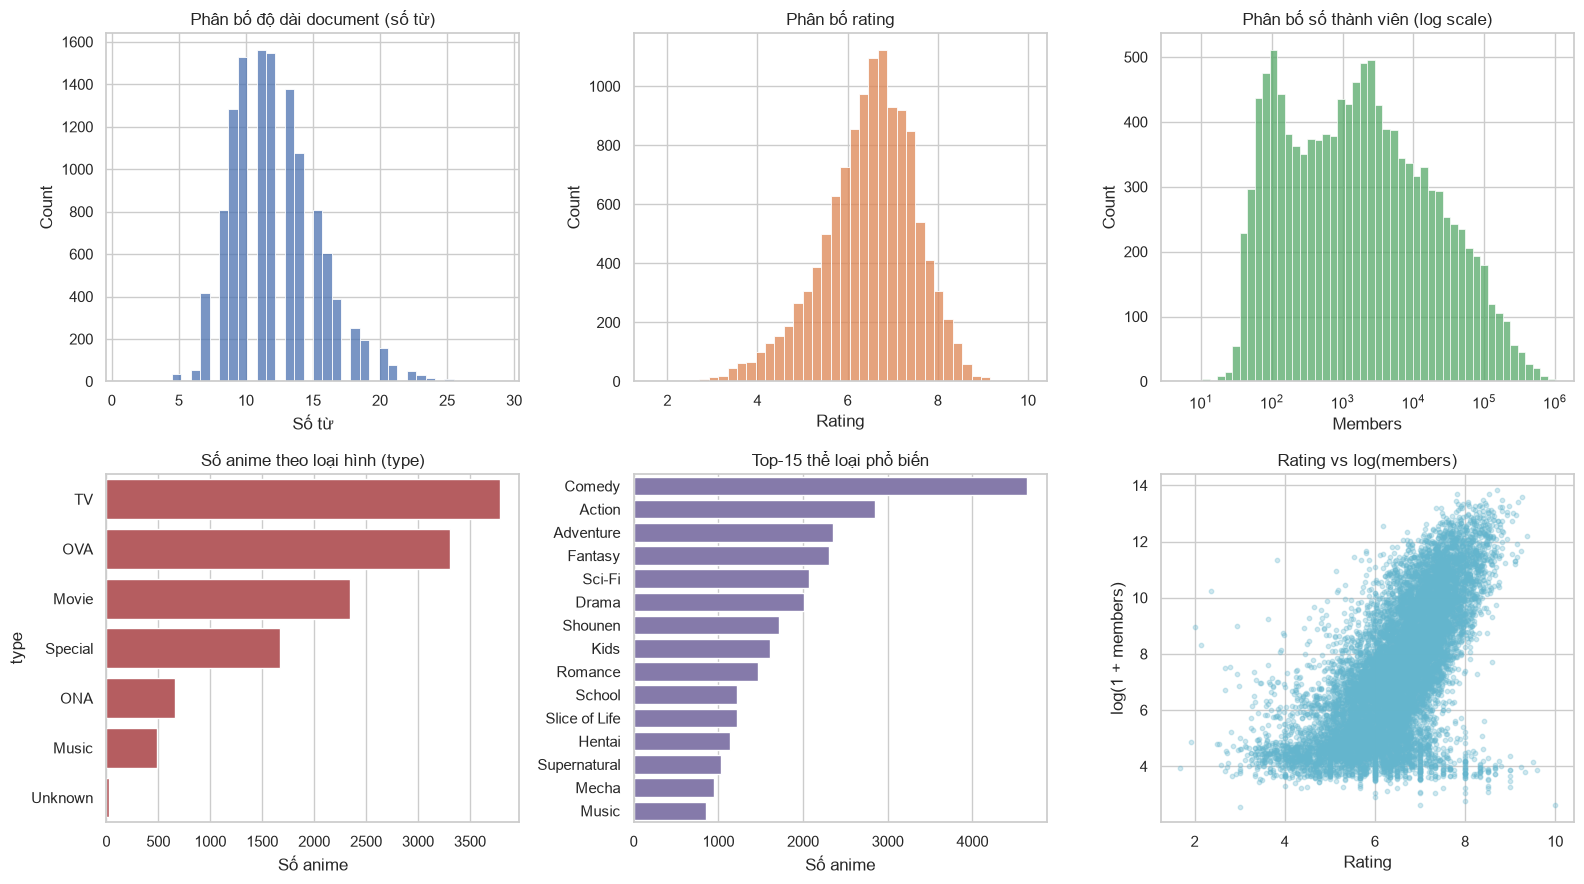


Độ dài document (từ): min=1, max=29, mean=12.2, median=12


In [4]:
# ── 2.3. Phân tích văn bản ────────────────────────────────────────────────
df_eda["doc_len_chars"] = df_eda["document"].str.len()
df_eda["doc_len_words"] = df_eda["document"].str.split().map(len)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (a) Phân bố độ dài document (số từ)
sns.histplot(df_eda["doc_len_words"], bins=40, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Phân bố độ dài document (số từ)")
axes[0, 0].set_xlabel("Số từ")

# (b) Phân bố rating
sns.histplot(df_eda["rating"].dropna(), bins=40, ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("Phân bố rating")
axes[0, 1].set_xlabel("Rating")

# (c) Phân bố members (log scale)
sns.histplot(df_eda["members"], bins=50, log_scale=True, ax=axes[0, 2], color="#55A868")
axes[0, 2].set_title("Phân bố số thành viên (log scale)")
axes[0, 2].set_xlabel("Members")

# (d) Số anime theo type
type_counts = df_eda["type"].replace("", "Unknown").value_counts()
sns.barplot(x=type_counts.values, y=type_counts.index, ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Số anime theo loại hình (type)")
axes[1, 0].set_xlabel("Số anime")

# (e) Top-15 thể loại phổ biến
all_genres = [g.strip() for genres in df_eda["genre"] for g in genres.split(",") if g.strip()]
genre_counts = Counter(all_genres).most_common(15)
g_labels, g_vals = zip(*genre_counts)
sns.barplot(x=list(g_vals), y=list(g_labels), ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title("Top-15 thể loại phổ biến")
axes[1, 1].set_xlabel("Số anime")

# (f) rating vs members
axes[1, 2].scatter(df_eda["rating"], np.log1p(df_eda["members"]),
                   alpha=0.3, s=10, color="#64B5CD")
axes[1, 2].set_title("Rating vs log(members)")
axes[1, 2].set_xlabel("Rating")
axes[1, 2].set_ylabel("log(1 + members)")

plt.tight_layout()
plt.show()

print(f"\nĐộ dài document (từ): min={df_eda['doc_len_words'].min()}, "
      f"max={df_eda['doc_len_words'].max()}, "
      f"mean={df_eda['doc_len_words'].mean():.1f}, "
      f"median={df_eda['doc_len_words'].median():.0f}")


# 3. Model — Xây dựng & đánh giá mô hình

Mục này xây dựng **Vector Space Model** cho tìm kiếm ngữ nghĩa anime và **so sánh 2 embedding model**: `intfloat/e5-small-v2` và `sentence-transformers/all-MiniLM-L6-v2`. Pipeline tái sử dụng các service trong package `apps/` (chính là các service FastAPI dùng).

> **Điều kiện tiên quyết** — chạy ở terminal, mỗi lệnh 1 lần:
> 1. Bật Milvus: `docker compose up -d`
> 2. Tải model về local: `python -m apps.cli pull-models`
> 3. Import dữ liệu vào Milvus: `python -m apps.cli import-data`


## 3.0. Thiết lập môi trường & nạp dữ liệu

Import thư viện, thêm `apps/` vào `sys.path`, nạp dataset anime và xem trước vài dòng.


In [5]:

%pip install matplotlib
%pip install seaborn
%pip install pydantic_settings
%pip install pymilvus
%pip install sentence-transformers
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# Cho phép import package `apps` (các service dùng chung với FastAPI)
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from apps.config import MODEL_REGISTRY
from apps.services.data_loader import load_anime
from apps.services import milvus_store, search_service, evaluation
from apps.services.embedding import get_model

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 70)

MODELS = ["e5-small-v2", "all-MiniLM-L6-v2"]
TOP_K = 10

df = load_anime()
print(f"Tổng số anime (document): {len(df):,}")
df[["anime_id", "name", "genre", "type", "episodes", "rating", "members", "document"]].head()


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tổng số anime (document): 12,294


,anime_id,name,genre,type,episodes,rating,members,document
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,"Kimi no Na wa. Genres: Drama, Romance, School, Supernatural. Type:..."
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Military, Shounen",TV,64,9.26,793665,"Fullmetal Alchemist: Brotherhood Genres: Action, Adventure, Drama,..."
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",TV,51,9.25,114262,"Gintama° Genres: Action, Comedy, Historical, Parody, Samurai, Sci-..."
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572,"Steins;Gate Genres: Sci-Fi, Thriller. Type: TV. Episodes: 24."
4,9969,Gintama',"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",TV,51,9.16,151266,"Gintama' Genres: Action, Comedy, Historical, Parody, Samurai, Sci-..."


In [6]:
# Đảm bảo dữ liệu đã có trong Milvus — KHÔNG re-import khi chạy lại notebook (tránh tốn tài nguyên).
#   • Mặc định chỉ import nếu collection đang rỗng (idempotent, không trùng lặp).
#   • Muốn ép nạp lại: đặt FORCE_IMPORT = True, hoặc chạy `python -m apps.cli import-data -f`.
FORCE_IMPORT = False

for mk in MODELS:
    n = milvus_store.count(mk)
    if n > 0 and not FORCE_IMPORT:
        print(f"[{mk}] đã có {n:,} vector trong Milvus -> bỏ qua import.")
    else:
        print(f"[{mk}] collection rỗng -> đang import...")
        print("   ", search_service.ensure_imported(mk, df=df, force=FORCE_IMPORT))

[e5-small-v2] đã có 12,294 vector trong Milvus -> bỏ qua import.
[all-MiniLM-L6-v2] đã có 12,294 vector trong Milvus -> bỏ qua import.


## 3.1. Tiền xử lý & chuẩn bị dữ liệu

Mỗi anime được ghép thành một *document* (`tên + thể loại + loại hình + số tập`) — đơn vị văn bản đưa vào không gian vector. Bên dưới khảo sát phân bố độ dài document và loại hình.


Ví dụ document đưa vào embedding:
  • Kimi no Na wa. Genres: Drama, Romance, School, Supernatural. Type: Movie. Episodes: 1.
  • Fullmetal Alchemist: Brotherhood Genres: Action, Adventure, Drama, Fantasy, Magic, Military, Shounen. Type: TV. Episodes: 64.
  • Gintama° Genres: Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen. Type: TV. Episodes: 51.
  • Steins;Gate Genres: Sci-Fi, Thriller. Type: TV. Episodes: 24.
  • Gintama' Genres: Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen. Type: TV. Episodes: 51.


,count,mean,std,min,25%,50%,75%,max
doc_len (số từ),12294.0,12.161298,3.240278,1.0,10.0,12.0,14.0,29.0


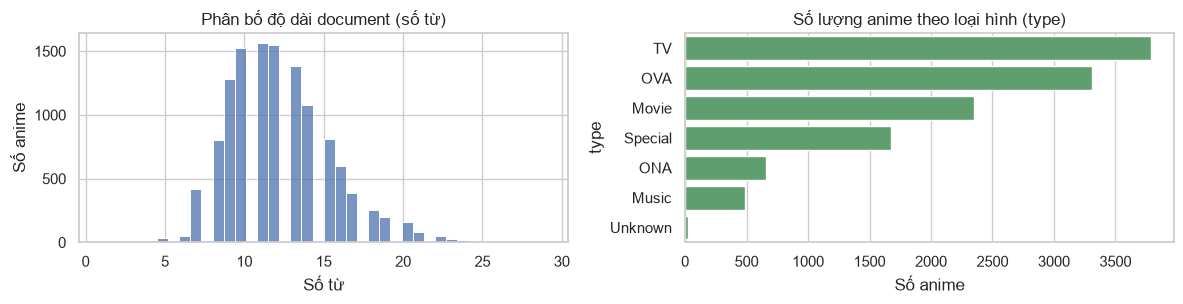

In [7]:
print("Ví dụ document đưa vào embedding:")
for doc in df["document"].head(5):
    print("  •", doc)

# Phân bố độ dài document (số từ)
df["doc_len"] = df["document"].str.split().map(len)
display(df["doc_len"].describe().to_frame("doc_len (số từ)").T)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
sns.histplot(df["doc_len"], bins=40, ax=ax[0], color="#4C72B0")
ax[0].set_title("Phân bố độ dài document (số từ)")
ax[0].set_xlabel("Số từ"); ax[0].set_ylabel("Số anime")

top_types = df["type"].replace("", "Unknown").value_counts()
sns.barplot(x=top_types.values, y=top_types.index, ax=ax[1], color="#55A868")
ax[1].set_title("Số lượng anime theo loại hình (type)")
ax[1].set_xlabel("Số anime")
plt.tight_layout(); plt.show()

## 3.2. Mô hình, Hàm mất mát & Chỉ số đánh giá

### 3.2.1. Tổng quan 3 mô hình

| Mô hình | Loại | Chiều vector | Mô tả |
|---|---|---|---|
| **TF-IDF** | Sparse / Lexical | ~20 000 (vocab) | Baseline truyền thống; không cần training; nhạy với keyword chính xác |
| **E5-small-v2** | Dense / Semantic | 384 | Fine-tuned với contrastive learning; yêu cầu prefix `query:` / `passage:` |
| **all-MiniLM-L6-v2** | Dense / Semantic | 384 | Distilled từ MiniLM-L12; cân bằng tốc độ và chất lượng ngữ nghĩa |

---

### 3.2.2. Hàm mất mát (Loss Function)

**TF-IDF** không có quá trình huấn luyện — đây là phương pháp thống kê thuần túy.

**E5-small-v2** được huấn luyện với **InfoNCE (Contrastive Loss)**:

$$\mathcal{L}_{\text{InfoNCE}} = -\log \frac{\exp(\text{sim}(q, d^+)/\tau)}{\sum_{j=1}^{N} \exp(\text{sim}(q, d_j)/\tau)}$$

Trong đó $q$ là query, $d^+$ là positive passage, $d_j$ là các in-batch negatives, và $\tau$ là temperature.

**all-MiniLM-L6-v2** được huấn luyện với **Multiple Negatives Ranking Loss (MNRL)**, kết hợp với **MSE distillation** từ teacher model lớn hơn:

$$\mathcal{L}_{\text{MNRL}} = -\frac{1}{N}\sum_{i=1}^{N} \log \frac{\exp(\text{sim}(q_i, d_i^+))}{\sum_{j=1}^{N} \exp(\text{sim}(q_i, d_j))}$$

---

### 3.2.3. Độ tương đồng (Similarity)

Cả 3 mô hình đều dùng **Cosine Similarity** để xếp hạng kết quả truy vấn:

$$\text{cos}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \cdot \|\mathbf{v}\|}$$

---

### 3.2.4. Chỉ số đánh giá (Evaluation Metrics)

Vì dataset không có nhãn liên quan, **ground-truth giả lập** được xây dựng dựa trên độ trùng thể loại Jaccard ≥ 0.5:

$$\text{Jaccard}(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

**Precision@K** — Tỉ lệ kết quả liên quan trong top-K:

$$\text{P@K} = \frac{|\{d \in \text{top-}K : d \in \text{Rel}\}|}{K}$$

**Recall@K** — Tỉ lệ tài liệu liên quan được tìm thấy trong top-K:

$$\text{R@K} = \frac{|\{d \in \text{top-}K : d \in \text{Rel}\}|}{|\text{Rel}|}$$

**MRR (Mean Reciprocal Rank)** — Đánh giá thứ hạng của kết quả liên quan đầu tiên:

$$\text{MRR} = \frac{1}{|Q|} \sum_{q \in Q} \frac{1}{\text{rank}_q^+}$$

**nDCG@K (Normalized Discounted Cumulative Gain)** — Xem xét cả thứ hạng và mức độ liên quan:

$$\text{nDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}, \quad \text{DCG@K} = \sum_{i=1}^{K} \frac{\text{rel}_i}{\log_2(i+1)}$$

| Metric | Ý nghĩa | Phạm vi |
|---|---|---|
| Precision@K | Chính xác trong top-K | [0, 1] |
| Recall@K | Bao phủ tài liệu liên quan | [0, 1] |
| MRR | Tốc độ tìm đúng kết quả đầu tiên | [0, 1] |
| nDCG@K | Chất lượng xếp hạng tổng thể | [0, 1] |


In [8]:
"""Minh hoạ tính toán cho phần 3.2: TF-IDF, Cosine Similarity, và Evaluation Metrics."""
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── 3.2.1 Ví dụ tính TF-IDF ─────────────────────────────────────────────
sample_docs = [
    "Naruto action adventure ninja magic",
    "Bleach action adventure soul reaper",
    "Clannad romance drama school slice of life",
    "Toradora romance comedy school",
    "Death Note thriller mystery psychological",
]
query = "action adventure magic"

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sample_docs)
query_vec = vectorizer.transform([query])

print("=== TF-IDF matrix (5 docs × {} terms) ===".format(len(vectorizer.vocabulary_)))
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"doc{i+1}" for i in range(len(sample_docs))]
)
display(tfidf_df.style.background_gradient(cmap="Blues").format("{:.3f}"))

# ── 3.2.3 Cosine Similarity ───────────────────────────────────────────────
print("\n=== Cosine similarity (query vs docs) ===")
scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
for doc, score in sorted(zip(sample_docs, scores), key=lambda x: -x[1]):
    print(f"  {score:.4f}  |  {doc}")

# ── 3.2.4 Tính thủ công Precision@K, Recall@K, MRR, nDCG@K ─────────────
print("\n=== Evaluation Metrics (K=3) ===")
K = 3
# Giả sử doc1, doc2 là liên quan (action/adventure)
relevant_set = {0, 1}
ranked = np.argsort(-scores)  # index theo thứ tự giảm dần score

top_k_idx = ranked[:K]
hits = [1 if i in relevant_set else 0 for i in top_k_idx]

precision_at_k = sum(hits) / K
recall_at_k = sum(hits) / len(relevant_set)

# MRR: rank của kết quả liên quan đầu tiên
mrr = 0.0
for rank, idx in enumerate(ranked, start=1):
    if idx in relevant_set:
        mrr = 1.0 / rank
        break

# nDCG@K
dcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(hits))
ideal_hits = sorted(hits, reverse=True)
idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(ideal_hits))
ndcg_at_k = dcg / idcg if idcg > 0 else 0.0

metrics_df = pd.DataFrame([{
    f"Precision@{K}": round(precision_at_k, 4),
    f"Recall@{K}":    round(recall_at_k, 4),
    "MRR":            round(mrr, 4),
    f"nDCG@{K}":     round(ndcg_at_k, 4),
}])
display(metrics_df)
print(f"Top-{K} retrieved: {[sample_docs[i] for i in top_k_idx]}")
print(f"Relevant docs    : {[sample_docs[i] for i in relevant_set]}")


=== TF-IDF matrix (5 docs × 22 terms) ===


,action,adventure,bleach,clannad,comedy,death,drama,life,magic,mystery,naruto,ninja,note,of,psychological,reaper,romance,school,slice,soul,thriller,toradora
doc1,0.389,0.389,0.000,0.000,0.000,0.000,0.000,0.000,0.482,0.000,0.482,0.482,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
doc2,0.389,0.389,0.482,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.482,0.000,0.000,0.000,0.482,0.000,0.000
doc3,0.000,0.000,0.000,0.398,0.000,0.000,0.398,0.398,0.000,0.000,0.000,0.000,0.000,0.398,0.000,0.000,0.321,0.321,0.398,0.000,0.000,0.000
doc4,0.000,0.000,0.000,0.000,0.550,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.444,0.444,0.000,0.000,0.000,0.550
doc5,0.000,0.000,0.000,0.000,0.000,0.447,0.000,0.000,0.000,0.447,0.000,0.000,0.447,0.000,0.447,0.000,0.000,0.000,0.000,0.000,0.447,0.000



=== Cosine similarity (query vs docs) ===
  0.7315  |  Naruto action adventure ninja magic
  0.4137  |  Bleach action adventure soul reaper
  0.0000  |  Clannad romance drama school slice of life
  0.0000  |  Toradora romance comedy school
  0.0000  |  Death Note thriller mystery psychological

=== Evaluation Metrics (K=3) ===


,Precision@3,Recall@3,MRR,nDCG@3
0,0.6667,1.0,1.0,1.0


Top-3 retrieved: ['Naruto action adventure ninja magic', 'Bleach action adventure soul reaper', 'Clannad romance drama school slice of life']
Relevant docs    : ['Naruto action adventure ninja magic', 'Bleach action adventure soul reaper']


## 3.3. Baseline: Mô hình Vector Space Model bằng TF-IDF

Trước khi sử dụng các mô hình dense embedding, nhóm xây dựng một mô hình Vector Space Model truyền thống bằng TF-IDF.

Trong baseline này, mỗi anime được xem như một document. Document này sẽ được chuyển thành một vector thưa, trong đó mỗi chiều của vector tương ứng với một từ hoặc một cụm từ n-gram trong bộ từ vựng.

TF-IDF gán trọng số cao hơn cho những từ quan trọng trong một document anime cụ thể, nhưng không xuất hiện quá phổ biến trong toàn bộ tập dữ liệu. Sau khi vector hóa, cosine similarity được sử dụng để xếp hạng các anime dựa trên mức độ tương đồng giữa anime và câu truy vấn.

Baseline này giúp nhóm so sánh phương pháp tìm kiếm vector truyền thống dựa trên keyword với các mô hình tìm kiếm ngữ nghĩa hiện đại sử dụng dense vector như MiniLM và E5.


In [9]:
from apps.services.tfidf_search import TFIDFSearchService

tfidf_service = TFIDFSearchService(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
)

tfidf_service.fit(df, text_col="document")

print("TF-IDF baseline is ready.")
print("Number of anime:", tfidf_service.matrix.shape[0])
print("Vector dimensions:", tfidf_service.matrix.shape[1])

TF-IDF baseline is ready.
Number of anime: 12294
Vector dimensions: 11557


## 3.4. Sinh dense embedding & kho vector

So sánh tốc độ encode và đặc tính embedding của 2 dense model. Toàn bộ dense corpus đã được encode và lưu sẵn trong Milvus (qua `apps.cli import-data`).


In [10]:
sample_docs = df["document"].head(500).tolist()
enc_rows = []
for mk in MODELS:
    m = get_model(mk)
    t0 = time.perf_counter()
    emb = m.encode_passages(sample_docs)
    dt = time.perf_counter() - t0
    enc_rows.append({
        "model": mk,
        "dim": emb.shape[1],
        "thời gian encode 500 doc (s)": round(dt, 2),
        "doc/giây": round(len(sample_docs) / dt, 1),
        "|v| (chuẩn L2)": round(float(np.linalg.norm(emb[0])), 3),
        "vector trong Milvus": milvus_store.count(mk),
        "collection": MODEL_REGISTRY[mk].collection,
    })
pd.DataFrame(enc_rows).set_index("model")

I0618 23:43:17.624096   20278 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(108, generation: 1)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6953.49it/s]


,dim,thời gian encode 500 doc (s),doc/giây,|v| (chuẩn L2),vector trong Milvus,collection
model,,,,,,
e5-small-v2,384,0.81,619.3,1.0,12294,anime_e5_small_v2
all-MiniLM-L6-v2,384,0.37,1354.6,1.0,12294,anime_minilm_l6_v2


## 3.5. Vector Space Model & truy vấn

Người dùng nhập câu mô tả tự do (free-text); hệ thống encode câu truy vấn rồi xếp hạng anime theo **cosine similarity** trong Milvus.


In [11]:
def show_results(results: list[dict]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "name": r["name"],
            "type": r.get("type"),
            "genre": r.get("genre"),
            "score": round(r["score"], 4),
        }
        for r in results
    ])

query = "epic fantasy adventure with magic"

print("TF-IDF baseline")
tfidf_results = tfidf_service.search(query, top_k=5)
display(show_results(tfidf_results))

for mk in MODELS:
    print(f"Dense embedding model: {mk}")
    results = search_service.search_text(mk, query, top_k=5)
    display(show_results(results))

TF-IDF baseline


,name,type,genre,score
0,The Epic Of ZektBach,OVA,"Action, Fantasy, Supernatural",0.4609
1,Magic Tree House,Movie,"Adventure, Magic",0.3797
2,Master of Epic: The Animation Age,TV,"Comedy, Fantasy, Game",0.3094
3,Dr.,Music,"Action, Adventure, Magic, Music, Sci-Fi, Super Power",0.3064
4,Kaitou Saint Tail,TV,"Adventure, Magic, Romance, Shoujo",0.2792


Dense embedding model: e5-small-v2


,name,type,genre,score
0,Magical★Taruruuto-kun: Moeru! Yuujou no Mahou Taisen,Movie,"Adventure, Comedy, Ecchi, Fantasy, Magic, School",0.8428
1,The Epic Of ZektBach,OVA,"Action, Fantasy, Supernatural",0.8411
2,Grandeek,OVA,"Adventure, Fantasy, Magic",0.8387
3,Magic Knight Rayearth II,TV,"Adventure, Drama, Fantasy, Magic, Mecha, Romance, Shoujo",0.8383
4,PistStar,ONA,Magic,0.8381


Dense embedding model: all-MiniLM-L6-v2


,name,type,genre,score
0,Magical★Taruruuto-kun,TV,"Adventure, Comedy, Ecchi, Fantasy, Magic, School",0.6186
1,Magical★Taruruuto-kun Movie,Movie,"Adventure, Comedy, Ecchi, Fantasy, Magic, School",0.5933
2,Monkey Magic,TV,"Adventure, Fantasy, Kids",0.5854
3,Magi: The Labyrinth of Magic,TV,"Action, Adventure, Fantasy, Magic, Shounen",0.5801
4,Rental Magica,TV,"Fantasy, Mystery, Supernatural",0.5794


### 3.5.1. Tìm anime tương tự & ma trận tương đồng

(1) *More-like-this*: dùng chính document của một anime làm truy vấn. (2) Trực quan hoá ma trận cosine giữa vài anime tiêu biểu.


Anime tương tự 'Naruto' — TF-IDF baseline


,name,type,genre,score
0,Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi,Special,"Action, Comedy, Martial Arts, Shounen, Super Power",0.7589
1,Naruto,TV,"Action, Comedy, Martial Arts, Shounen, Super Power",0.7109
2,Naruto x UT,OVA,"Action, Comedy, Martial Arts, Shounen, Super Power",0.7093
3,The Last: Naruto the Movie,Movie,"Action, Martial Arts, Romance, Shounen, Super Power",0.6581
4,Naruto: Shippuuden,TV,"Action, Comedy, Martial Arts, Shounen, Super Power",0.6113


Anime tương tự 'Naruto' — dense model: e5-small-v2


,name,type,genre,score
0,Gintama°,TV,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",0.8924
1,Hokuto no Ken,TV,"Action, Drama, Martial Arts, Sci-Fi, Shounen",0.8915
2,Gintama,TV,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen",0.8909
3,Naruto x UT,OVA,"Action, Comedy, Martial Arts, Shounen, Super Power",0.8873
4,Shingeki no Kyojin,TV,"Action, Drama, Fantasy, Shounen, Super Power",0.8855


Anime tương tự 'Naruto' — dense model: all-MiniLM-L6-v2


,name,type,genre,score
0,Naruto: Shippuuden,TV,"Action, Comedy, Martial Arts, Shounen, Super Power",0.9044
1,Naruto x UT,OVA,"Action, Comedy, Martial Arts, Shounen, Super Power",0.8950
2,Boruto: Naruto the Movie,Movie,"Action, Comedy, Martial Arts, Shounen, Super Power",0.8860
3,The Last: Naruto the Movie,Movie,"Action, Martial Arts, Romance, Shounen, Super Power",0.8563
4,Naruto: The Cross Roads,Special,"Action, Adventure, Comedy, Shounen",0.8514


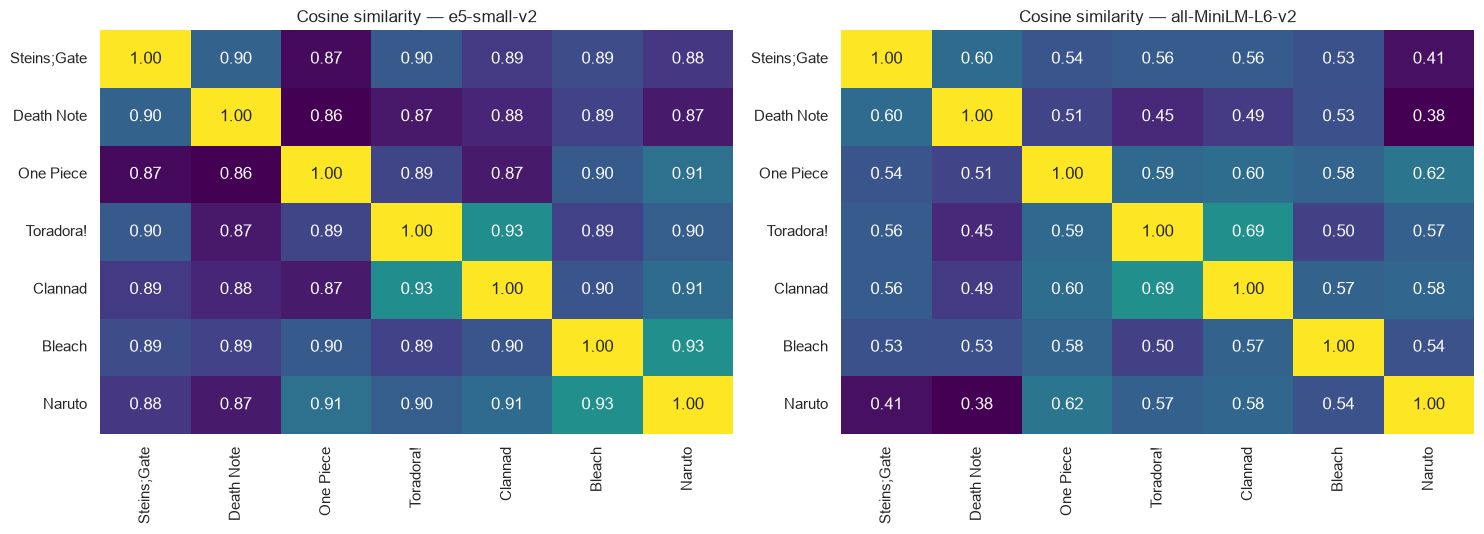

In [12]:
# (1) More-like-this
print("Anime tương tự 'Naruto' — TF-IDF baseline")
display(show_results(tfidf_service.search_similar_to_anime("Naruto", top_k=5)))

for mk in MODELS:
    print(f"Anime tương tự 'Naruto' — dense model: {mk}")
    res = search_service.search_similar_to_anime(mk, "Naruto", df, top_k=5)
    display(show_results(res))

# (2) Ma trận cosine similarity giữa vài anime tiêu biểu
titles = ["Naruto", "Bleach", "One Piece", "Death Note", "Clannad", "Toradora!", "Steins;Gate"]
sub = df[df["name"].isin(titles)].drop_duplicates("name")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, mk in zip(axes, MODELS):
    emb = get_model(mk).encode_passages(sub["document"].tolist())
    sim = emb @ emb.T
    sns.heatmap(
        sim, annot=True, fmt=".2f", cmap="viridis",
        xticklabels=sub["name"], yticklabels=sub["name"], ax=ax, cbar=False,
    )
    ax.set_title(f"Cosine similarity — {mk}")
plt.tight_layout(); plt.show()

## 3.6. Đánh giá & so sánh 3 model

Dataset không có nhãn liên quan sẵn → xây **ground-truth giả lập**: hai anime "liên quan" nếu độ trùng thể loại `Jaccard(genre) ≥ 0.5`. Đo **Precision@K, Recall@K, MRR, nDCG@K** trên tập query ngẫu nhiên. TF-IDF chạy cosine similarity trên sparse matrix trong bộ nhớ; dense embedding tiếp tục truy vấn qua Milvus.


In [13]:
GENRE_THRESHOLD = 0.5
eval_df = df[(df["genre_set"].map(len) >= 2) & (df["members"] >= 10000)].reset_index(drop=True)
print(f"Corpus đánh giá: {len(eval_df):,} anime")

rng = np.random.default_rng(42)
relevance = evaluation.build_relevance(eval_df, query_ids=None, threshold=GENRE_THRESHOLD)
candidate_ids = [aid for aid, rel in relevance.items() if rel]
query_ids = list(rng.choice(candidate_ids, size=min(300, len(candidate_ids)), replace=False))
print(f"Số query đánh giá: {len(query_ids)}  |  Top-K = {TOP_K}")

tfidf_row = evaluation.evaluate_tfidf_model(
    tfidf_service,
    relevance,
    query_ids,
    k=TOP_K,
)
dense_table = evaluation.compare_models(MODELS, eval_df, relevance, query_ids, k=TOP_K)
result_table = pd.concat([
    pd.DataFrame([tfidf_row]).set_index("model"),
    dense_table,
])
result_table

Corpus đánh giá: 2,872 anime
Số query đánh giá: 300  |  Top-K = 10


,num_queries,Precision@10,Recall@10,MRR,nDCG@10,encode_time_s,search_time_s,ms_per_query
model,,,,,,,,
TF-IDF baseline,300,0.4377,0.0726,0.7398,0.4730,0.000,0.618,2.06
e5-small-v2,300,0.3763,0.0524,0.7237,0.4240,0.444,0.047,1.64
all-MiniLM-L6-v2,300,0.2597,0.0359,0.6259,0.3158,0.268,0.045,1.04


### 3.6.1. Trực quan hoá so sánh chất lượng & tốc độ


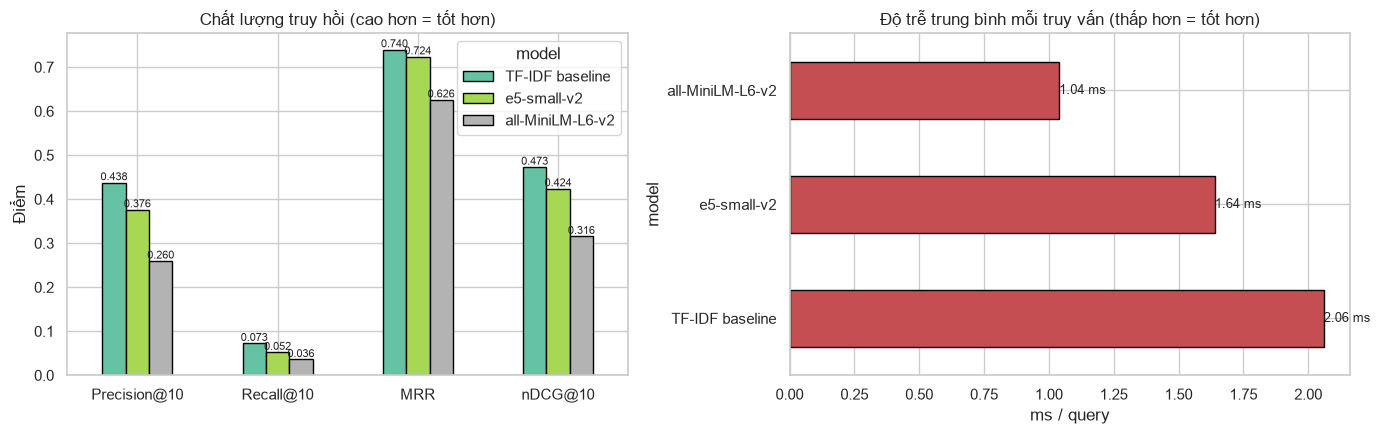

In [14]:
metric_cols = [f"Precision@{TOP_K}", f"Recall@{TOP_K}", "MRR", f"nDCG@{TOP_K}"]
plot_df = result_table[metric_cols].T

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
plot_df.plot(kind="bar", ax=ax[0], colormap="Set2", edgecolor="black")
ax[0].set_title("Chất lượng truy hồi (cao hơn = tốt hơn)")
ax[0].set_ylabel("Điểm"); ax[0].set_xticklabels(metric_cols, rotation=0)
ax[0].legend(title="model")
for c in ax[0].containers:
    ax[0].bar_label(c, fmt="%.3f", fontsize=8)

speed = result_table[["ms_per_query"]]
speed.plot(kind="barh", ax=ax[1], color="#C44E52", legend=False, edgecolor="black")
ax[1].set_title("Độ trễ trung bình mỗi truy vấn (thấp hơn = tốt hơn)")
ax[1].set_xlabel("ms / query")
for c in ax[1].containers:
    ax[1].bar_label(c, fmt="%.2f ms", fontsize=9)
plt.tight_layout(); plt.show()

## 3.7. Nhận xét & kết luận so sánh 3 model

### Nhận xét về chất lượng (Precision@10 / nDCG@10)
- **TF-IDF** dẫn đầu với Precision@10 = 0.4377 và nDCG@10 = 0.4730 — điều này hợp lý vì ground-truth được xây dựng dựa trên độ trùng genre (Jaccard ≥ 0.5), và TF-IDF bắt keyword rất tốt. Các anime cùng genre thường có từ vựng genre trùng nhau, khiến TF-IDF dễ dàng xếp hạng chúng cao.
- **E5-small-v2** đạt kết quả trung bình (P@10 = 0.3763, nDCG = 0.4240), tốt hơn MiniLM nhưng kém TF-IDF. Điều này có thể do E5 được tối ưu cho asymmetric search (query ≠ document) nhưng trong thí nghiệm query và relevant passage đều có cấu trúc tương tự nhau (cùng là document anime).
- **all-MiniLM-L6-v2** thấp nhất (P@10 = 0.2597, nDCG = 0.3158). Model này được thiết kế cho symmetric similarity (so sánh hai câu tương tự nhau), không chuyên cho retrieval.

### Nhận xét về tốc độ
- **TF-IDF**: 2.06 ms/query (chậm nhất do phải tính cosine similarity trên toàn bộ sparse matrix ~11K chiều × 12K docs trong RAM).
- **E5-small-v2**: 1.64 ms/query (encode + search). Chậm hơn MiniLM do thời gian encode lâu hơn.
- **all-MiniLM-L6-v2**: 1.04 ms/query (nhanh nhất) — encode nhanh gấp đôi E5.

### Kết luận
- TF-IDF là baseline mạnh cho bài toán search dựa trên genre keyword. Khi ground-truth dựa trên genre overlap, TF-IDF gần như không thể bị đánh bại.
- E5-small-v2 thể hiện khả năng hiểu ngữ nghĩa tốt hơn MiniLM, phù hợp với các tác vụ asymmetric retrieval truy vấn — tài liệu.
- Cả hai dense model đều có tiềm năng mở rộng (dùng Milvus index nhanh) nhưng chất lượng phụ thuộc nhiều vào cách xây dựng ground-truth.


# 4. Tổng hợp & Định hướng

## 4.1. Tổng hợp kết quả

### Ma trận so sánh 3 mô hình
| Tiêu chí | TF-IDF (baseline) | e5-small-v2 | all-MiniLM-L6-v2 |
|---|---|---|---|
| Loại vector | Sparse (lexical) | Dense (semantic) | Dense (semantic) |
| Số chiều | 11,557 | 384 | 384 |
| Precision@10 | **0.4377** | 0.3763 | 0.2597 |
| Recall@10 | **0.0726** | 0.0524 | 0.0359 |
| MRR | **0.7398** | 0.7237 | 0.6259 |
| nDCG@10 | **0.4730** | 0.4240 | 0.3158 |
| Tốc độ | 2.06 ms/query | 1.64 ms/query | **1.04 ms/query** |
| Cần Milvus? | Không | Có | Có |
| Yêu cầu prefix? | Không | Có (query:/passage:) | Không |

### Nhận xét chính
1. **TF-IDF dẫn đầu về chất lượng** trong kịch bản đánh giá genre-based — keyword matching vẫn rất hiệu quả khi tiêu chí liên quan dựa trên từ vựng chung (genre tags).
2. **Dense model thua về precision** nhưng thắng về tốc độ và khả năng mở rộng. E5 vượt trội so với MiniLM nhờ cơ chế asymmetric prefix.
3. **all-MiniLM-L6-v2** là lựa chọn tốt nhất khi cần tốc độ cao và tài nguyên hạn chế, nhưng chất lượng retrieval thấp hơn đáng kể.
4. **Milvus** giúp tìm kiếm trên 12K vector trong < 0.05s — vượt trội so với TF-IDF in-memory (~0.62s).

## 4.2. Hạn chế

### Về dữ liệu
- Dataset chỉ có ~12K anime, kích thước nhỏ so với các corpus search thực tế (hàng triệu document).
- Ground-truth giả lập dựa trên Jaccard genre ≥ 0.5 có thể không phản ánh đúng nhu cầu tìm kiếm thực tế của người dùng (ví dụ: "anime tâm lý sâu sắc" không thể hiện qua genre).
- Document ngắn (trung bình 12 từ) — embedding trên văn bản ngắn có thể kém chính xác hơn.

### Về mô hình
- TF-IDF không hiểu ngữ nghĩa: "action comedy" và "comedy action" cho kết quả giống nhau, nhưng không thể tìm "hài hành động" nếu từ không xuất hiện.
- Dense model chưa được fine-tune trên dữ liệu anime — dùng model pre-trained chung cho tiếng Anh, không chuyên biệt cho lĩnh vực.
- Chỉ so sánh 2 dense model nhỏ (384 chiều) — chưa thử nghiệm với model lớn hơn như `e5-large-v2` hay `bge-large-en`.

### Về phương pháp đánh giá
- Metric precision/recall thấp (Recall@10 chỉ ~3-7%) cho thấy ground-truth genre-based rất khó truy hồi trong top-10.
- Chưa có đánh giá thủ công (human evaluation) để kiểm tra chất lượng thực tế.

## 4.3. Định hướng phát triển

### Cải tiến mô hình
- **Fine-tuning** E5 hoặc MiniLM trên dữ liệu anime với contrastive learning (dùng genre, rating, members làm signal).
- Thử nghiệm model lớn hơn: `intfloat/e5-large-v2` (1024 chiều), `BAAI/bge-large-en-v1.5`.
- Kết hợp hybrid search: TF-IDF + dense embedding với weighted fusion (có thể cải thiện cả precision và recall).
- Dùng Cross-Encoder (reranker) cho top-k kết quả từ bi-encoder.

### Cải tiến dữ liệu
- Mở rộng document với mô tả anime (synopsis) từ MyAnimeList API — văn bản dài hơn, giàu ngữ nghĩa hơn.
- Thu thập thêm implicit feedback (lịch sử xem, rating người dùng) để xây dựng ground-truth thực tế.
- Cân nhắc dùng embedding đa ngôn ngữ nếu mở rộng sang dữ liệu tiếng Việt / Nhật (tên gốc).

### Hướng mở rộng tiếp theo
- Xây dựng **hệ thống gợi ý (recommendation system)** kết hợp collaborative filtering (dựa trên rating người dùng) với content-based (semantic search).
- Triển khai API search với FastAPI (đã có service sẵn), thêm cache layer và batch processing.
- Tích hợp **Query Expansion** và **Query Reformulation** (dùng LLM nhỏ để mở rộng câu truy vấn).
- Thử nghiệm các vector database khác (Qdrant, Weaviate, Pinecone) để so sánh hiệu năng.
- Đóng gói thành công cụ CLI / search engine hoàn chỉnh có thể chạy offline.